# State-evolution validation

This notebook compares the finite self-training recursion with the current Monte Carlo effective dynamics in four settings:

1. balanced classes with an intercept;
2. balanced classes without an intercept (Bayes-optimal);
3. imbalanced classes with an intercept;
4. imbalanced classes without an intercept (Misspecified).

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    plot_macroscopic_evolution,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    macroscopic_discrepancy,
    run_experiment,
    state_evolution_state_observables,
    state_evolution_update_observables,
)

The two particle budgets below intentionally differ: $K_w$ and $K_g$ are numerical integration budgets, not finite dimensions and not constrained by $K_g/K_w=\bar\delta$.

In [4]:
SEED = 42
BAR_DELTA = 2.0
SIGMA = 1.0
RHO = 0.1
T = 75
D = 5_000
N_TEST = 5_000
K_W = 6_000
K_G = 7_500

In [5]:
def run_case(*, name, label_prior, include_bias, signal_std, seed=SEED):
    """Run one shared-helper finite/SE validation case."""
    algo_cfg = make_algorithm_config(
        T=T, eta=0.1, penalty=0.1, pi=5.0,
        kappa=logit(0.8), include_bias=include_bias,
    )
    assert algo_cfg.is_canonical_fixed_pi
    return run_experiment(
        name=name,
        d=D,
        delta=BAR_DELTA,
        n_test=N_TEST,
        label_prior=label_prior,
        rho=RHO,
        sigma=SIGMA,
        signal_std=signal_std,
        algo_cfg=algo_cfg,
        seed=seed,
        K_w=K_W,
        K_g=K_G,
        metadata={"theorem_external": not include_bias},
    )

## Run the four validation cases

The no-bias cases are retained as controlled empirical variants and are marked theorem-external in the result metadata.  There is no burn-in/ramp schedule in this notebook: omitted schedule fields mean the canonical fixed-$\pi$ recursion, including the $t=0$ pseudo-labelled term.

In [6]:
CASE_SPECS = (
    dict(name="balanced, bias", label_prior=0.5, include_bias=True, signal_std=0.5),
    dict(name="balanced, no bias", label_prior=0.5, include_bias=False, signal_std=1.0),
    dict(name="imbalanced, bias", label_prior=0.2, include_bias=True, signal_std=1.0),
    dict(name="imbalanced, no bias", label_prior=0.2, include_bias=False, signal_std=1.0),
)

results = {
    spec["name"]: run_case(**spec, seed=SEED + 100 * index)
    for index, spec in enumerate(CASE_SPECS)
}

for name, result in results.items():
    env = result.environment
    print(
        f"{name}: n={env.n}, d={env.d}, N={env.N}, M={env.M}, "
        f"delta_finite={env.delta:.3f}, "
        f"theorem_external={result.metadata['theorem_external']}"
    )

balanced, bias: n=10000, d=5000, N=1028, M=8972, delta_finite=2.000, theorem_external=False
balanced, no bias: n=10000, d=5000, N=1028, M=8972, delta_finite=2.000, theorem_external=True
imbalanced, bias: n=10000, d=5000, N=1007, M=8993, delta_finite=2.000, theorem_external=False
imbalanced, no bias: n=10000, d=5000, N=1036, M=8964, delta_finite=2.000, theorem_external=True


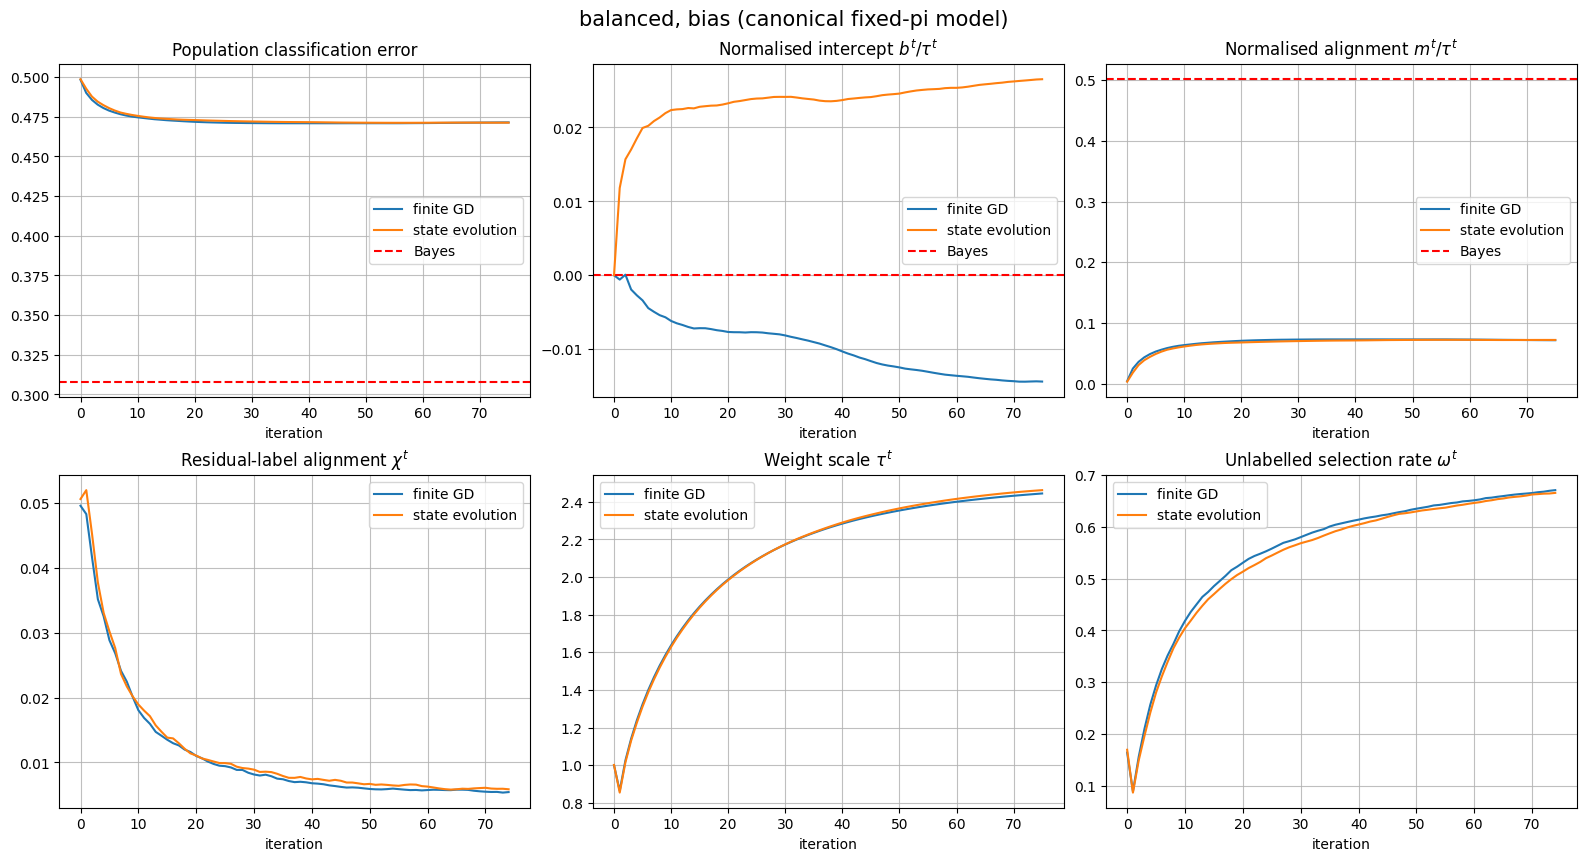

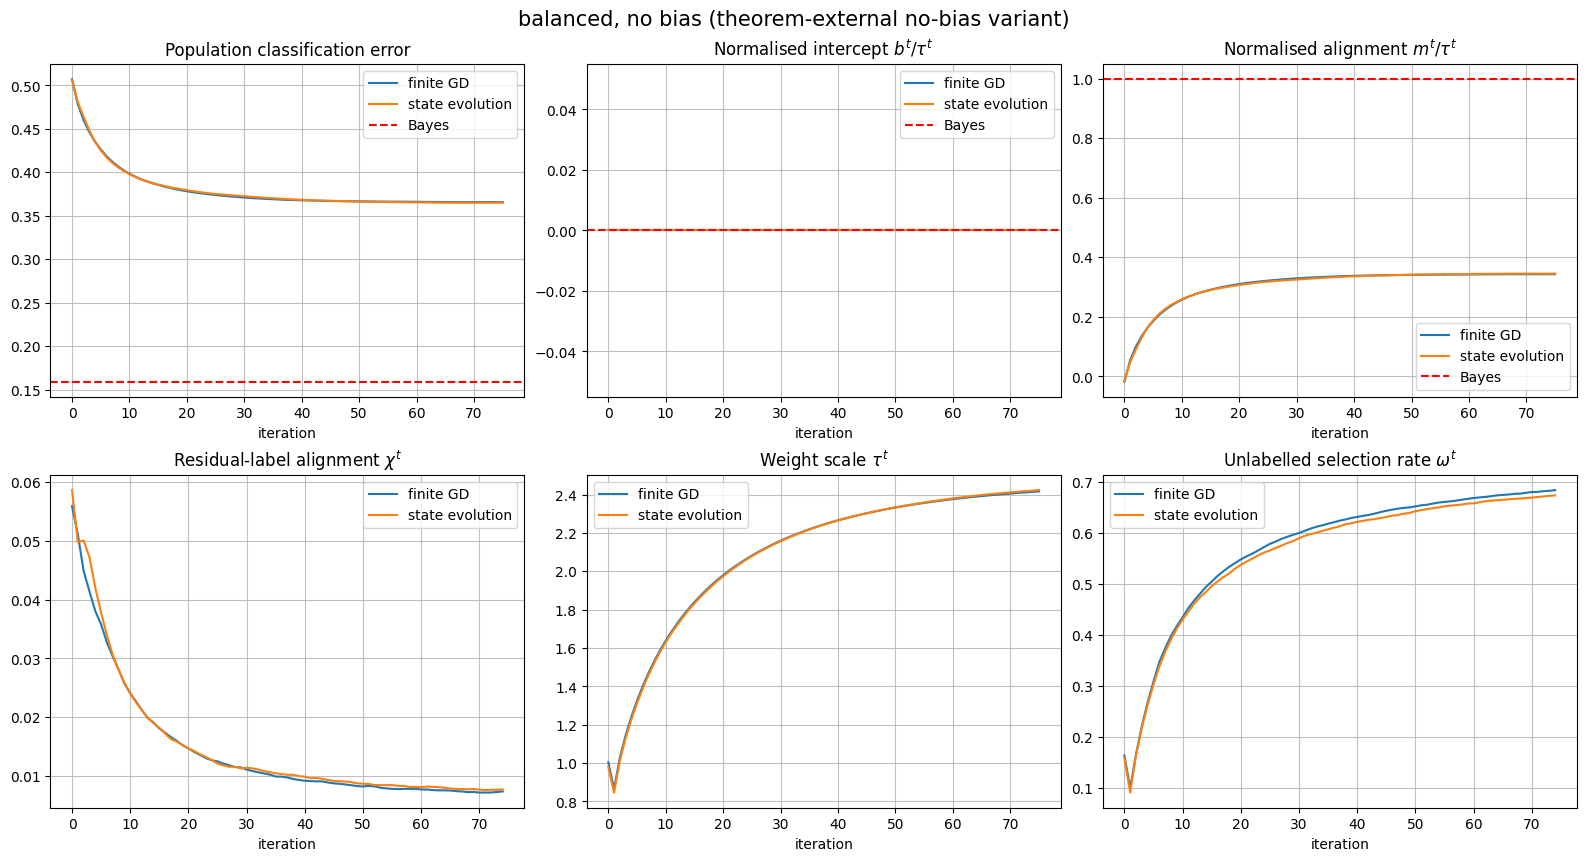

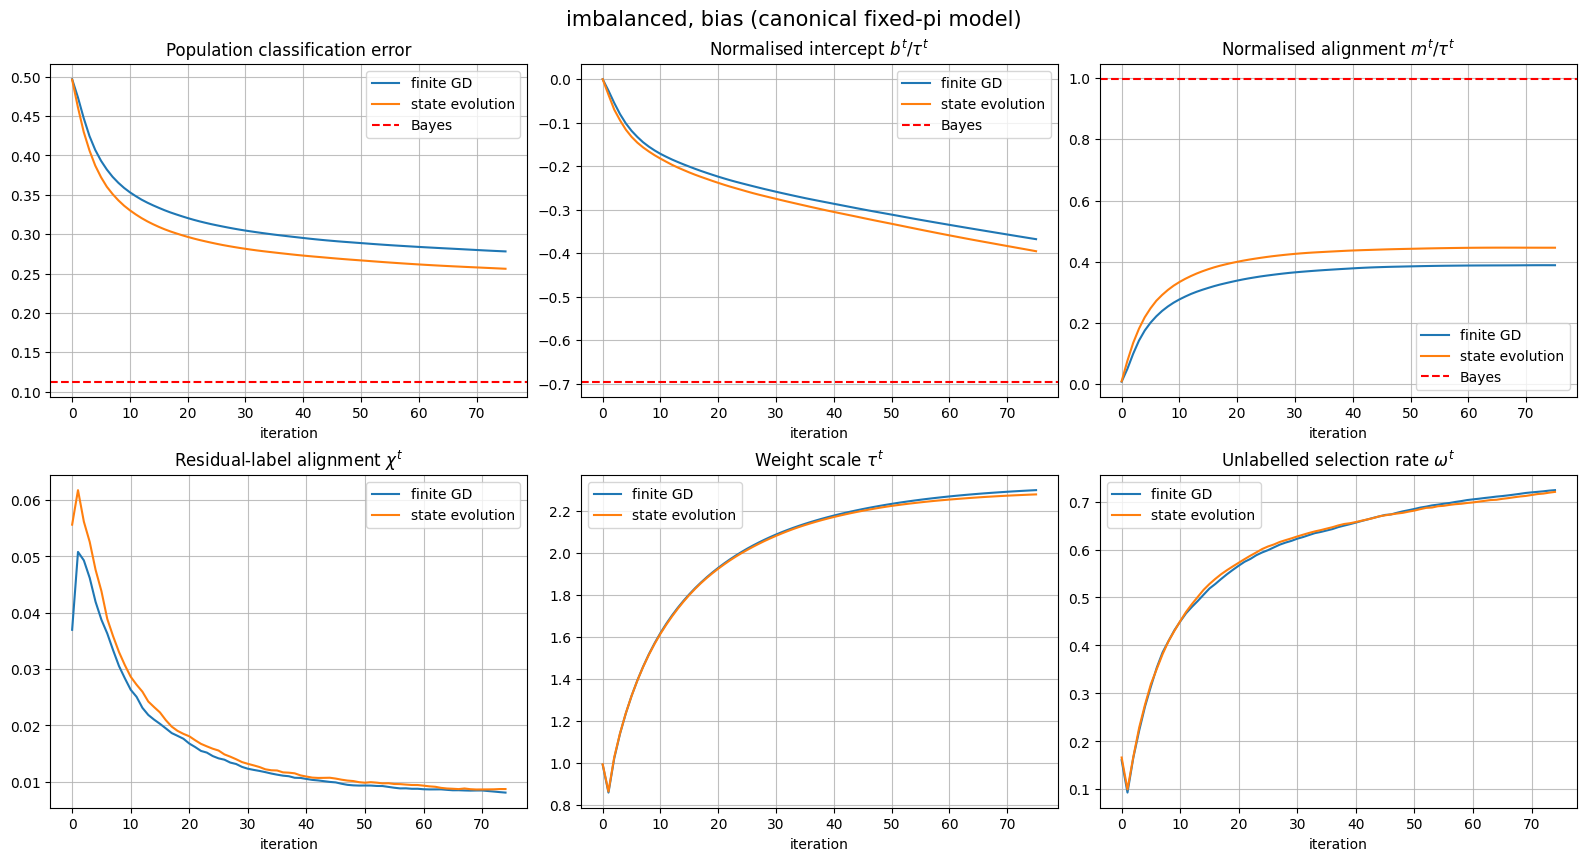

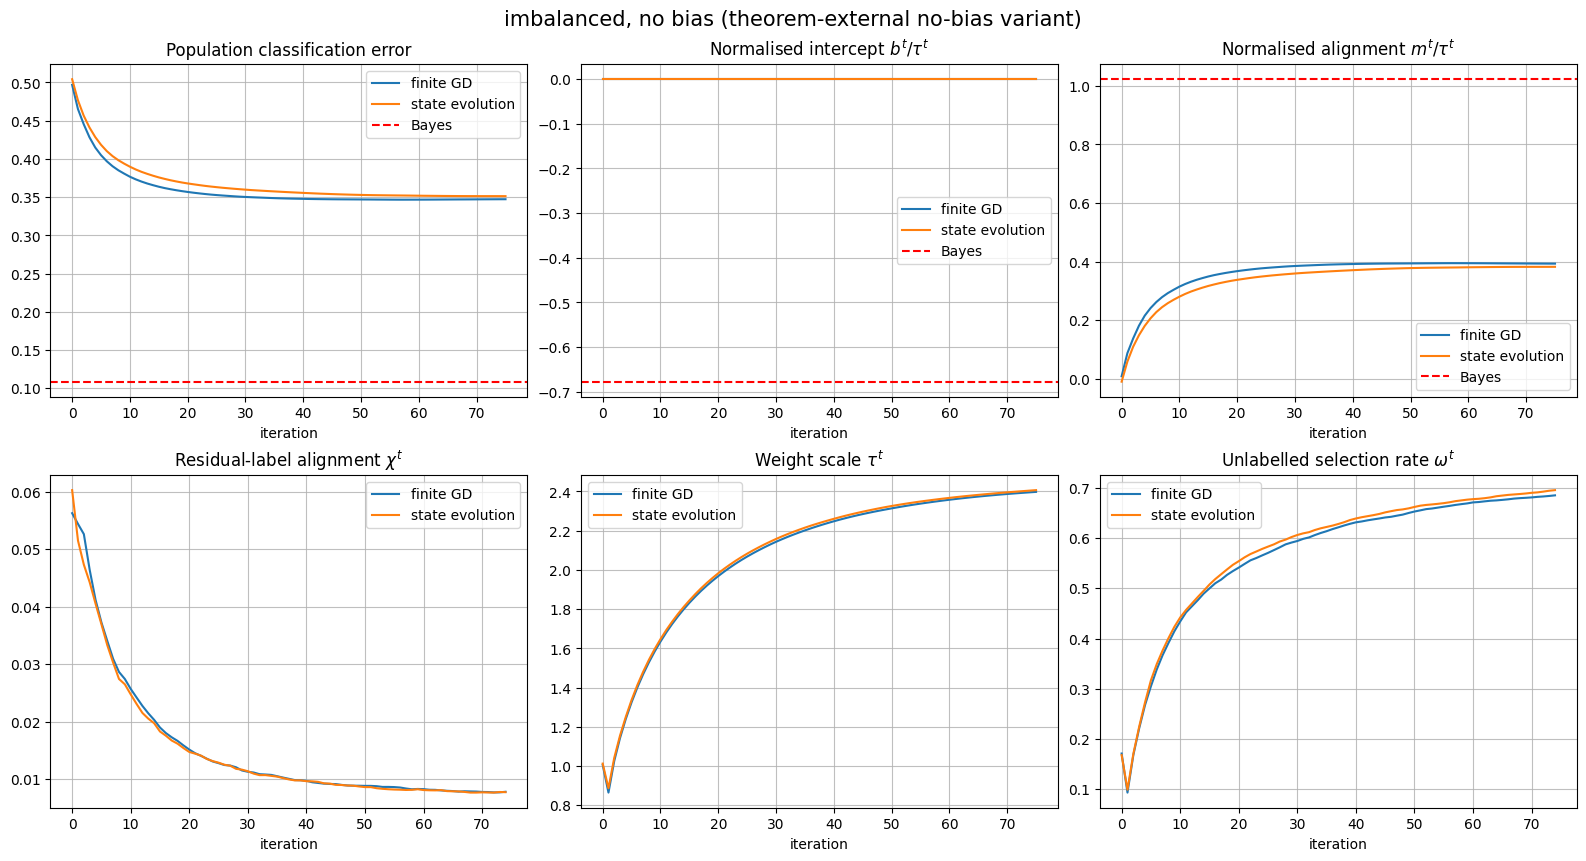

In [7]:
for result in results.values():
    plot_macroscopic_evolution(result)

## Effective-dynamics diagnostics

The following checks inspect the projection geometry directly.  In particular, empirical orthogonality is with respect to the normalized inner products: $B_w^\top B_w/K_w=I$ and $B_g^\top B_g/K_g=I$.

In [8]:
for name, result in results.items():
    se = result.se
    theorem = se.theorem_trajectory
    print(f"\n{name}")
    print(f"  theorem lengths: |W|={len(theorem.W)}, |Q|={len(theorem.Q)}, |R|={len(theorem.R)}, |G|={len(theorem.G)}, |P|={len(theorem.P)}")
    print(f"  auxiliary terminal diagnostics available: g^T={se.residual[T] is not None}, p^T={se.backward_noise[T] is not None}")
    print(f"  final ranks: r_w={se.weight_rank[T]}, r_g={se.residual_rank[T]}")
    print(f"  final orthogonality errors: w={float(se.weight_orthogonality_error[T]):.2e}, g={float(se.residual_orthogonality_error[T]):.2e}")
    print(f"  innovation dimensions: z_g^T={tuple(se.z_g[T].shape)}, z_w^T={tuple(se.z_w[T].shape)}")


balanced, bias
  theorem lengths: |W|=76, |Q|=76, |R|=76, |G|=75, |P|=75
  auxiliary terminal diagnostics available: g^T=True, p^T=True
  final ranks: r_w=76, r_g=76
  final orthogonality errors: w=6.34e-15, g=6.00e-15
  innovation dimensions: z_g^T=(7500,), z_w^T=(6000,)

balanced, no bias
  theorem lengths: |W|=76, |Q|=76, |R|=76, |G|=75, |P|=75
  auxiliary terminal diagnostics available: g^T=True, p^T=True
  final ranks: r_w=76, r_g=76
  final orthogonality errors: w=6.67e-15, g=3.78e-15
  innovation dimensions: z_g^T=(7500,), z_w^T=(6000,)

imbalanced, bias
  theorem lengths: |W|=76, |Q|=76, |R|=76, |G|=75, |P|=75
  auxiliary terminal diagnostics available: g^T=True, p^T=True
  final ranks: r_w=76, r_g=76
  final orthogonality errors: w=5.12e-15, g=4.89e-15
  innovation dimensions: z_g^T=(7500,), z_w^T=(6000,)

imbalanced, no bias
  theorem lengths: |W|=76, |Q|=76, |R|=76, |G|=75, |P|=75
  auxiliary terminal diagnostics available: g^T=True, p^T=True
  final ranks: r_w=76, r_g=76
 

## Interpretation

A finite run and a particle approximation should not coincide pathwise: the finite design, quenched environment, and the two state-evolution particle populations are separate draws.  The meaningful validation criterion is agreement of the macroscopic trajectories up to finite-$d$ and finite-$K$ fluctuations.  

The discrepancies could be explained by the ranks, the CGS2 orthogonality errors, the condition numbers of the small coordinate matrices, the aspect-ratio check, and whether the same fixed-$\pi$/initialization semantics were used.

These plots are therefore qualitative diagnostics, not an asymptotic validation by themselves: a single finite environment and a single particle approximation cannot separate finite-dimensional fluctuations, particle Monte Carlo error, and a systematic discrepancy.  The fixed-horizon repeated sweep below supplies quantitative max-norm discrepancies and keeps the two uncertainty sources distinct.  Its canonical comparisons are the bias-enabled cases; the no-bias runs remain theorem-external empirical controls.